In [1]:
%load_ext autoreload
%autoreload 2

import json
import os
import yaml
from pathlib import Path
from dask.distributed import Client
import dask.dataframe as dd
import networkx as nx
import sys
import pandas as pd
import ipycytoscape
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import intervals
import pygtrie
import seaborn as sns
import gc


/usr/workspace/pandey2/DFT/envDFT/lib/python3.9/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [2]:
use_local=False
if not use_local:
    with open(f'/g/g91/pandey2/.dftracer/configuration.yaml', 'r') as file:
        dlp_yaml = yaml.safe_load(file)
        app_root = dlp_yaml["app"]
else:
    app_root = str(Path(os.getcwd()).parent.parent)
sys.path.insert(0, app_root)

import dfanalyzer
print(dfanalyzer.__file__)
from dfanalyzer.main import DFAnalyzer,get_dft_configuration,update_dft_configuration,setup_logging,setup_dask_cluster, reset_dask_cluster, get_dft_configuration
from dfanalyzer.graph_visualization.cytoscape import GraphFunctions, CytoGraph
from dfanalyzer.graph1 import DFGrepInterference, DFGrepWorkflow, DFGrepBurstiness 

if not use_local:
    dask_run_dir = os.path.join(app_root, "dfanalyzer", "dask", "run_dir")
    with open (os.path.join(dask_run_dir, f"scheduler_{os.getenv('USER')}.json"), "r") as f:
        dask_scheduler = json.load(f)["address"]
else:
    dask_scheduler = None

# App Name
# app_name = "montage-pegasus-2mass-2deg-4node" #cosmoflow cm1
# app_name = "1000_genome_pegasus_node_16"
# app_name = "cm1"
# app_name = "deepspeed-dlio-step100"
# app_name = " deepspeed-dlio-scr-step100"
# app_name = "bert"
app_name = "unet3d"
# app_name = "resnet50"

condition_fn = None #

if app_name == "cm1":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/cm1/APP/node-32/v1/COMPACT/*.pfw.gz"
    cp_dir = "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name == "cosmoflow":
    # filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/cosmoflow/dlio-v100/node-16/v1/COMPACT/*.pfw.gz"
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/cosmoflow/dlio-v100/node-4/v1/COMPACT/*1*.pfw.gz"
    cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name == "deepspeed-dlio-step100":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.6-develop/corona/megatron-deepspeed/dlio-step100/node-16/v1/COMPACT/*.pfw.gz"
    cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name == "deepspeed-dlio-scr-step100":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.6-develop/corona/megatron-deepspeed/dlio-scr-step100/node-16/v1/COMPACT/*.pfw.gz"
    cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name == "montage-mpi-2mass-7deg":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/montage/mpi-2mass-7deg/node-16/v1/RAW/*.pfw.gz"
    cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name =="montage-pegasus-2mass-2deg-4node":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/montage/pegasus-2mass-2deg/node-4/v1/COMPACT/*.pfw.gz"
    # filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/montage/pegasus-2mass-2deg/node-4/v1/RAW/*.pfw.gz"
    filename = "/p/lustre3/pandey2/logs/RAW_copy/montage-pegasus-2mass-2deg-4node/RAW/*.pfw.gz" # Raw Copied
    cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name == "resnet50":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/resnet50/dlio-v100/node-4/v1/COMPACT/*.pfw.gz"
    cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name == "unet3d":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/unet3d/dlio-v100/node-16/v2/COMPACT/*.pfw.gz"
    cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name == "bert":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/bert/v100/node-16/v1/COMPACT/*.pfw.gz"
    cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name == "1000_genome_pegasus_node_16":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/1000-genome/pegasus/node-16/v3/COMPACT/*.pfw.gz"
    cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"
    
else:
    raise Exception("Unknown App name")


# Configuration 4 update log file dlp -> df
conf = update_dft_configuration(dask_scheduler=dask_scheduler, verbose=True, debug=True,
                                log_file=f"./dft_{os.getenv('USER')}.log", rebuild_index=False, time_approximate=True, 
                                host_pattern=r'lassen(\d+)', time_granularity=30e6, skip_hostname=True, conditions=condition_fn)
conf = get_dft_configuration()


# Setup
setup_logging()
setup_dask_cluster()
reset_dask_cluster()

[INFO] [14:33:39] Initialized Client with 48 workers and link http://134.9.71.20:8787/status [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:769]


/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/__init__.py


[INFO] [14:33:43] Restarting all workers [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:761]


In [3]:
def all_mount_points():
    with open("/proc/mounts", "r") as file:
        mount_points = [line.split()[1] for line in file]
    with open("/usr/workspace/pandey2/lassen_mounts", "r") as file:
        mount_p = [line.split()[1] for line in file]
    return mount_points+mount_p

mount_points = all_mount_points()
trie = pygtrie.StringTrie(zip(mount_points, [True] * len(mount_points)))


In [4]:
def cols_function(json_object, current_dict, time_approximate,condition_fn,load_data):
    d = {}
    def find_mount_point(path,trie):
        mount_point = trie.longest_prefix(path)
        if mount_point:
            return mount_point.key
        return '/'.join(path.split('/', 3)[:3])

    if "M" == json_object["ph"] and "FH" == json_object["name"] and "args" in json_object and "name" in json_object["args"]:
        d["mount_point"] = find_mount_point(trie=load_data["mount_point"],path=json_object["args"]["name"])
    if "args" in json_object and "M" != json_object["ph"]:
        if "ret" in json_object["args"]:
            d["size"] = int(json_object["args"]["ret"]) 
    return d

load_cols = {'size': "int64[pyarrow]" }
load_cols_metadata = {"FH":{'mount_point':"string[pyarrow]" }}

In [5]:
analyzer = DFAnalyzer(filename,load_fn=cols_function, load_cols=load_cols, load_data={"mount_point":trie}, metadata_cols = load_cols_metadata)

[INFO] [14:33:56] Created index for 2 files [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:428]
[INFO] [14:33:56] Total size of all files are <dask.bag.core.Item object at 0x15554172df40> bytes [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:430]
[INFO] [14:33:56] test debug [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:433]
[INFO] [14:33:57] Loading 740 batches out of 2 files and has 12110283 lines overall [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:444]
[INFO] [14:34:31] Loaded events [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:511]
[INFO] [14:34:31] Loaded plots with slope threshold: 45 [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:517]


In [ ]:
# x = analyzer.events.compute()
# x.fhash.nunique()
# x.pid.nunique()
# x.hhash.nunique()
# len(x)


In [15]:
'''
Information needed for burstiness analysis: "mount point", "size", "duration" "ts", "te" "name"
pipeline:
For Each
Output:
    for data(read & write) metadata()
    Number of Bursts:
        for Each bursts: [ts,te, number of evensts, total duration, total size]
 steps:
    df[operation type]: read/write/metadata
    df.groupby(mount_point, operation_type,)
    df[qurery]: read, write, metadata 
    

'''

'\nInformation needed for burstiness analysis: "mount point", "size", "duration" "ts", "te" "name"\npipeline:\nFor Each\nOutput:\n    for data(read & write) metadata()\n    Number of Bursts:\n        for Each bursts: [ts,te, number of evensts, total duration, total size]\n steps:\n    df[operation type]: read/write/metadata\n    df.groupby(mount_point, operation_type,)\n    df[qurery]: read, write, metadata \n    \n\n'

In [ ]:
if app_name in ["deepspeed-dlio-step100","deepspeed-dlio-scr-step100","resnet50","unet3d"]:
    df1 = analyzer.events[~analyzer.events['fhash'].isna()] 
    df2 = analyzer.file_hash.reset_index()[["hash", "mount_point"]]
    df3 = analyzer.host_hash.reset_index()[['hhash', 'name']]
    result_df = df1.merge(df2, left_on="fhash", right_on="hash", how='left').drop(columns = ['hash_x', 'hash_y', 'mount_point_x']).rename(columns={'mount_point_y': 'mount_point'})
    result_df1 = result_df.merge(df3, on="hhash", how='left', suffixes=('_left', '_right')).rename(columns={'name_left': 'name', 'name_right':'hostname'})
    analyze_df = result_df1[['name','cat','size','ts','te','dur','trange','mount_point','hostname']] 
    analyze_df['id'] = analyze_df.index
    analyze_df["mount_point"] = analyze_df["mount_point"].where(analyze_df["mount_point"].str.startswith("/"), "/p/lustre3")
    data_calls = ['read', 'write', 'fread', 'fwrite', 'pread', 'pwrite']
    data_df = analyze_df[analyze_df["name"].isin(data_calls)]
    metadata_df = analyze_df[~analyze_df["name"].isin(data_calls)]

elif app_name == "montage-pegasus-2mass-2deg-4node":
    df1 = analyzer.events[~analyzer.events['fhash'].isna()] 
    df2 = analyzer.file_hash.reset_index()[["hash", "mount_point"]]
    df3 = analyzer.host_hash.reset_index()[['hash', 'name']] 
    df3 = df3.rename(columns={'hash':'hhash'})
    result_df = df1.merge(df2, left_on="fhash", right_on="hash", how='left').drop(columns = ['hash_x', 'hash_y', 'mount_point_x']).rename(columns={'mount_point_y': 'mount_point'})
    result_df1 = result_df.merge(df3, on="hhash", how='left', suffixes=('_left', '_right')).rename(columns={'name_left': 'name', 'name_right':'hostname'})
    analyze_df = result_df1[['name','cat','size','ts','te','dur','trange','mount_point','hostname']] 
    analyze_df['id'] = analyze_df.index
    analyze_df["mount_point"] = analyze_df["mount_point"].where(analyze_df["mount_point"].str.startswith("/"), "/p/lustre3")
    data_calls = ['read', 'write', 'fread', 'fwrite', 'pread', 'pwrite']
    data_df = analyze_df[analyze_df["name"].isin(data_calls)]
    metadata_df = analyze_df[~analyze_df["name"].isin(data_calls)]

elif app_name in ["1000_genome_pegasus_node_16"]:
    df1 = analyzer.events[~analyzer.events['fhash'].isna()] 
    df2 = analyzer.file_hash.reset_index()[["hash", "mount_point"]]
    df3 = analyzer.host_hash.reset_index()[['hhash', 'name']] 
    result_df = df1.merge(df2, left_on="fhash", right_on="hash", how='left').drop(columns = ['hash_x', 'hash_y', 'mount_point_x']).rename(columns={'mount_point_y': 'mount_point'})
    result_df1 = result_df.merge(df3, on="hhash", how='left', suffixes=('_left', '_right')).rename(columns={'name_left': 'name', 'name_right':'hostname'})
    analyze_df = result_df1[['name','cat','size','ts','te','dur','trange','mount_point','hostname']] 
    analyze_df['id'] = analyze_df.index
    analyze_df["mount_point"] = analyze_df["mount_point"].where(analyze_df["mount_point"].str.startswith("/"), "/p/lustre3")
    data_calls = ['read', 'write', 'fread', 'fwrite', 'pread', 'pwrite']
    data_df = analyze_df[analyze_df["name"].isin(data_calls)]
    metadata_df = analyze_df[~analyze_df["name"].isin(data_calls)]


elif app_name == "bert":
    df1 = analyzer.events[~analyzer.events['fhash'].isna()] 
    df2 = analyzer.file_hash.reset_index()[["hash", "mount_point"]]
    df1['fhash'] = df1['fhash'].str.replace('.0', '', regex=False)  # Remove '.0'
    df3 = analyzer.host_hash.reset_index()[['hash', 'name']] 
    df3 = df3.rename(columns={'hash':'hhash'}) # update needed for this specific dataset
    result_df = df1.merge(df2, left_on="fhash", right_on="hash", how='left').drop(columns = ['hash_x', 'hash_y', 'mount_point_x']).rename(columns={'mount_point_y': 'mount_point'})
    result_df1 = result_df.merge(df3, on="hhash", how='left', suffixes=('_left', '_right')).rename(columns={'name_left': 'name', 'name_right':'hostname'})
    analyze_df = result_df1[['name','cat','size','ts','te','dur','trange','mount_point','hostname']] 
    analyze_df['id'] = analyze_df.index
    analyze_df["mount_point"] = analyze_df["mount_point"].where(analyze_df["mount_point"].str.startswith("/"), "/p/lustre3")
    data_calls = ['read', 'write', 'fread', 'fwrite', 'pread', 'pwrite']
    data_df = analyze_df[analyze_df["name"].isin(data_calls)]
    metadata_df = analyze_df[~analyze_df["name"].isin(data_calls)]

elif app_name in ["cm1"]:
    df1 = analyzer.events[~analyzer.events['fhash'].isna()] 
    df2 = analyzer.file_hash.reset_index()[["hash", "mount_point"]]
    df1['fhash'] = df1['fhash'].str.replace('.0', '', regex=False)  # Remove '.0'
    df1['hhash'] = df1['hhash'].str.replace('.0', '', regex=False)  # Remove '.0'
    df3 = analyzer.host_hash.reset_index()[['hash', 'name']] 
    df3 = df3.rename(columns={'hash':'hhash'}) # update needed for this specific dataset
    result_df = df1.merge(df2, left_on="fhash", right_on="hash", how='left').drop(columns = ['hash_x', 'hash_y', 'mount_point_x']).rename(columns={'mount_point_y': 'mount_point'})
    result_df1 = result_df.merge(df3, on="hhash", how='left', suffixes=('_left', '_right')).rename(columns={'name_left': 'name', 'name_right':'hostname'})
    analyze_df = result_df1[['name','cat','size','ts','te','dur','trange','mount_point','hostname']] 
    analyze_df['id'] = analyze_df.index
    analyze_df["mount_point"] = analyze_df["mount_point"].where(analyze_df["mount_point"].str.startswith("/"), "/p/lustre3")
    data_calls = ['read', 'write', 'fread', 'fwrite', 'pread', 'pwrite']
    data_df = analyze_df[analyze_df["name"].isin(data_calls)]
    metadata_df = analyze_df[~analyze_df["name"].isin(data_calls)]


In [7]:
data_df.head()

,name,cat,size,ts,te,dur,trange,mount_point,hostname,id
3018,read,POSIX,7889,37374245,37374251,6,1,/usr/WS2,corona245,3018
3019,read,POSIX,0,37374312,37374313,1,1,/usr/WS2,corona245,3019
3922,read,POSIX,38881,37519009,37519042,33,1,/collab/usr/gapps,corona245,3922
3923,read,POSIX,0,37519239,37519241,2,1,/collab/usr/gapps,corona245,3923
3930,read,POSIX,1888,37519878,37519882,4,1,/usr/WS2,corona245,3930


In [ ]:
# df1 = analyzer.events[~analyzer.events['fhash'].isna()] 
# df2 = analyzer.file_hash.reset_index()[["hash", "mount_point"]]
# df3 = analyzer.host_hash.reset_index()[['hhash', 'name']]
# result_df = df1.merge(df2, left_on="fhash", right_on="hash", how='left').drop(columns = ['hash_x', 'hash_y', 'mount_point_x']).rename(columns={'mount_point_y': 'mount_point'})
# result_df1 = result_df.merge(df3, on="hhash", how='left', suffixes=('_left', '_right')).rename(columns={'name_left': 'name', 'name_right':'hostname'})
# analyze_df = result_df1[['name','cat','size','ts','te','dur','trange','mount_point','hostname']] 
# analyze_df['id'] = analyze_df.index
# # analyze_df.name.unique().compute()
# data_calls = ['read', 'write', 'fread', 'fwrite', 'pread', 'pwrite']
# data_df = analyze_df[analyze_df["name"].isin(data_calls)]
# metadata_df = analyze_df[~analyze_df["name"].isin(data_calls)]

In [9]:
delta = data_df.dur.max().compute()
data_df.head()

,name,cat,size,ts,te,dur,trange,mount_point,hostname,id
3018,read,POSIX,7889,37374245,37374251,6,1,/usr/WS2,corona245,3018
3019,read,POSIX,0,37374312,37374313,1,1,/usr/WS2,corona245,3019
3922,read,POSIX,38881,37519009,37519042,33,1,/collab/usr/gapps,corona245,3922
3923,read,POSIX,0,37519239,37519241,2,1,/collab/usr/gapps,corona245,3923
3930,read,POSIX,1888,37519878,37519882,4,1,/usr/WS2,corona245,3930


In [10]:
delta

np.int64(133036)

In [ ]:

delta = data_df.dur.max().compute()
BurstCalculator = DFGrepBurstiness(data_df, app_name=app_name, operation="data", delta = delta, cp_dir=cp_dir, existing=False)
BurstCalculator.compute_burstiness()
BurstCalculator.write_checkpoint(id="ddf_bur",cp_dir=cp_dir)
# BurstCalculator.ddf_bur.compute()

#

In [12]:
BurstCalculator.ddf_bur.head()

,id,name,cat,size,ts,te,dur,trange,mount_point,hostname,group_key,b_id
0,333723,write,POSIX,32,4597199,4597203,4,0,/dev,corona221,"(0, '/dev', 'corona221')",333723
1,333724,write,POSIX,-1,4597210,4597215,5,0,/dev,corona221,"(0, '/dev', 'corona221')",333723
2,333725,write,POSIX,24,4597222,4597225,3,0,/dev,corona221,"(0, '/dev', 'corona221')",333723
3,333729,write,POSIX,32,4597259,4597263,4,0,/dev,corona221,"(0, '/dev', 'corona221')",333723
4,169625,write,POSIX,32,4597269,4597274,5,0,/dev,corona221,"(0, '/dev', 'corona221')",333723


In [16]:
cp_dir

'/p/lustre3/pandey2/logs/results_checkpoint'

Dask DataFrame Structure:
                   id    name     cat            size               ts               te              dur           trange mount_point hostname group_key   b_id
npartitions=24                                                                                                                                                 
                int64  string  string  int64[pyarrow]  uint64[pyarrow]  uint64[pyarrow]  uint64[pyarrow]  uint16[pyarrow]      string   string    string  int64
                  ...     ...     ...             ...              ...              ...              ...              ...         ...      ...       ...    ...
...               ...     ...     ...             ...              ...              ...              ...              ...         ...      ...       ...    ...
                  ...     ...     ...             ...              ...              ...              ...              ...         ...      ...       ...    ...
              

In [ ]:
p = 

In [17]:
x.to_parquet(f"{dir}/unetdd/data.parquet", compression="gzip", engine="pyarrow")
# x.to_parquet(f"{dir}/unetdd/s.parquet")

In [ ]:

dir = "/usr/workspace/pandey2/g_analyzer/B_notebooks/temp"
BurstCalculator.ddf_bur.to_parquet(f"{dir}/unetdd",
                            name_function=lambda i: f'xx-{i}.parquet',schema = pyarrow.Schema )
# BurstCalculator.ddf_bur.to_parquet()

NameError: name 'pyarrow' is not defined

In [18]:
df = pd.read_parquet("/usr/workspace/pandey2/g_analyzer/B_notebooks/temp/unetdd/data.parquet", engine="pyarrow")

In [19]:
df

,id,name,cat,size,ts,te,dur,trange,mount_point,hostname,b_id
0,333723,write,POSIX,32,4597199,4597203,4,0,/dev,corona221,333723
1,333724,write,POSIX,-1,4597210,4597215,5,0,/dev,corona221,333723
2,333725,write,POSIX,24,4597222,4597225,3,0,/dev,corona221,333723
3,333729,write,POSIX,32,4597259,4597263,4,0,/dev,corona221,333723
4,169625,write,POSIX,32,4597269,4597274,5,0,/dev,corona221,333723
...,...,...,...,...,...,...,...,...,...,...,...
8843,216440,read,POSIX,14,49528787,49528795,8,1,/sys,corona239,181784
8844,52339,read,POSIX,3,49528841,49528850,9,1,/sys,corona239,181784
8845,52342,read,POSIX,14,49528903,49528911,8,1,/sys,corona239,181784
8846,298486,read,POSIX,3,49529082,49529092,10,1,/sys,corona239,181784


In [25]:
cp_dir

'/p/lustre3/pandey2/logs/results_checkpoint'

In [26]:
BurstCalculator.ddf_bur.head()

,id,name,cat,size,ts,te,dur,trange,mount_point,hostname,b_id
0,217826,write,POSIX,32,4335561,4335565,4,0,/dev,corona278,217826
1,217827,write,POSIX,-1,4335573,4335577,4,0,/dev,corona278,217826
2,217828,write,POSIX,24,4335584,4335587,3,0,/dev,corona278,217826
3,217832,write,POSIX,32,4335625,4335628,3,0,/dev,corona278,217826
4,375922,write,POSIX,32,4335633,4335639,6,0,/dev,corona278,217826


In [27]:
outfile=cp_dir+"/"+app_name+"/"+"data_burst.csv"
outfile

'/p/lustre3/pandey2/logs/results_checkpoint/resnet50/data_burst.csv'

In [28]:
BurstCalculator.ddf_bur.compute().to_csv(outfile)

In [24]:
BurstCalculator.ddf_bur.dtypes

index                    int64
id             string[pyarrow]
name           string[pyarrow]
cat            string[pyarrow]
size                     int64
ts                       int64
te                       int64
dur                      int64
trange                   int64
mount_point    string[pyarrow]
hostname       string[pyarrow]
b_id                     int64
dtype: object

In [ ]:
# delta_metadata = metadata_df.dur.max().compute()
# BurstCalculator_metadata = DFGrepBurstiness(metadata_df, app_name=app_name, operation="metadata", delta = delta, cp_dir=cp_dir, existing=False)
# BurstCalculator_metadata.compute_burstiness()

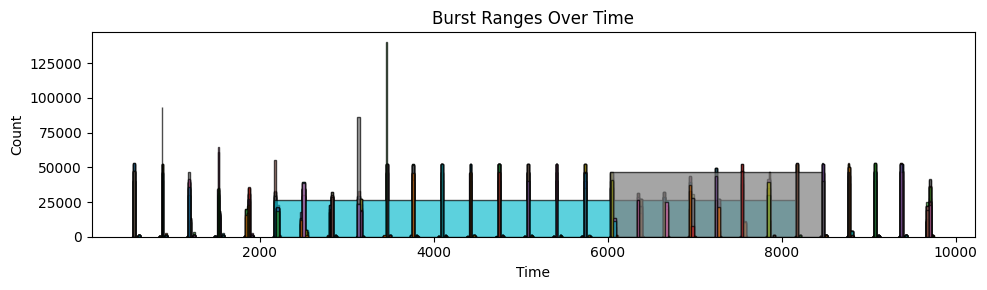

In [ ]:
import matplotlib.pyplot as plt

# Example burst data
start_times = result1['ts']
end_times = result1['te']
counts = result1['count']

# Bar width = end - start
widths = [end - start for start, end in zip(start_times, end_times)]

# All bars at y=0 since burst ID doesn't matter
y_position = [0] * len(start_times)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 3))

for i in range(len(start_times)):
    ax.bar(
        x=start_times[i],     # left edge of the bar
        height=counts[i],     # height of the bar = count
        width=widths[i],      # width = end - start
        bottom=0,
        align='edge',
        edgecolor='black',
        alpha=0.7,
        label=f"Burst {i+1}"
    )

ax.set_xlabel("Time")
ax.set_ylabel("Count")
ax.set_title("Burst Ranges Over Time")
# ax.legend()
# plt.grid(True, axis='x')
plt.tight_layout()
plt.show()


# deepspeed-100

In [6]:
df1 = analyzer.events[~analyzer.events['fhash'].isna()] 
df2 = analyzer.file_hash.reset_index()[["hash", "mount_point"]]
df3 = analyzer.host_hash.reset_index()[['hhash', 'name']]
result_df = df1.merge(df2, left_on="fhash", right_on="hash", how='left').drop(columns = ['hash_x', 'hash_y', 'mount_point_x']).rename(columns={'mount_point_y': 'mount_point'})
result_df1 = result_df.merge(df3, on="hhash", how='left', suffixes=('_left', '_right')).rename(columns={'name_left': 'name', 'name_right':'hostname'})
analyze_df = result_df1[['name','cat','size','ts','te','dur','trange','mount_point','hostname']] 
analyze_df['id'] = analyze_df.index

## Identify data and metada calls 

In [7]:
# analyze_df.name.unique().compute()
data_calls = ['read', 'write', 'fread', 'fwrite', 'mmap', 'mmap64']
metadata_calls = [
    '__lxstat64', '__xstat64', 'readlink', 'open64', '__fxstat64', 'lseek64', 
    'close', 'opendir', 'mkdir', 'fopen', 'fclose', 'access', '__xstat', 'link', 
    'unlink', 'fseek', 'rmdir', 'fopen64', 'ftell', 'ftruncate', '__fxstat', 
    'lseek', 'fcntl', 'dup2'
]

# Define the size bins
bins = [
    0, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 
    2048, 4096, 8192, 16384, 32768, 65536, 
    131072, 262144, 524288, 1048576, float('inf')
]

# Define the corresponding labels
bin_labels = [
    '1-4', '4-8', '8-16', '16-32', '32-64', '64-128', '128-256', '256-512', '512-1024', 
    '1024-2048', '2048-4096', '4096-8192', '8192-16384', '16384-32768', 
    '32768-65536', '65536-131072', '131072-262144', '262144-524288', 
    '524288-1048576', '1048576+'
]

# Use `map_partitions` with `pd.cut` to create a new column
def categorize_sizes(df):
    df['size_category'] = pd.cut(df['size'], bins=bins, labels=bin_labels)
    return df
def categorize_sizes_metadata(df):
    df['size_category'] = "size"
    return df


data_df = analyze_df[analyze_df["name"].isin(data_calls)]
metadata_df = analyze_df[analyze_df["name"].isin(metadata_calls)]


#

In [ ]:
data_df = data_df[data_df["size"] > 1]
data_df = data_df.map_partitions(categorize_sizes)
data_df['size_category'] = data_df['size_category'].astype('string[pyarrow]')

In [ ]:
metadata_df = metadata_df.query("dur > 0")
metadata_df["size"] = 0 
metadata_df = metadata_df.map_partitions(categorize_sizes_metadata)
metadata_df['size_category'] = metadata_df['size_category'].astype('string[pyarrow]')

mount_point_list = ["/collab","/dev","/dev/shm","/p/lustre3","/proc","/sys","/usr/workspace","/var/tmp"]
metadata_df = metadata_df[analyze_df["mount_point"].isin(mount_point_list)]


## Data Interference calculation

In [10]:
# data_df = data_df.query("size > 1")
IFCalculator = DFGrepInterference(data_df, app_name=app_name, operation="data", cp_dir=cp_dir, existing=False)


In [11]:
IFCalculator.get_degree()

In [12]:
IFCalculator.compute_interference()

[INFO] [14:32:04] Computing interference for data events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:186]
[INFO] [14:32:04] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:132]


[INFO] [14:32:46] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:134]


In [13]:
IFCalculator.write_checkpoint(id="inter",cp_dir=cp_dir)

## Metadata Interference Calculation

In [9]:
metadata_df.groupby("mount_point").count().compute()

,name,cat,size,ts,te,dur,trange,hostname,id
mount_point,,,,,,,,,
./,256,256,0,256,256,256,256,256,256
/collab,74112,74112,0,74112,74112,74112,74112,74112,74112
/collab/usr,74112,74112,0,74112,74112,74112,74112,74112,74112
/collab/usr/gapps,1414350,1414350,117848,1414350,1414350,1414350,1414350,1414350,1414350
/dev,19681,19681,4437,19681,19681,19681,19681,19681,19681
/dev/shm,1806306,1806306,385681,1806306,1806306,1806306,1806306,1806306,1806306
/etc/crypto-policies,1024,1024,0,1024,1024,1024,1024,1024,1024
/etc/libfabric.conf,256,256,0,256,256,256,256,256,256
/etc/libibverbs.d,5376,5376,0,5376,5376,5376,5376,5376,5376


In [9]:
# metadata_df["size_category"] = 'size'
# metadata_df["size"] = metadata_df['size_category'].astype('string[pyarrow]')
# data_df = data_df.query("size > 1")
IFCalculator_Metadata = DFGrepInterference(metadata_df, app_name=app_name, operation="metadata", cp_dir=cp_dir, existing=False)

In [10]:
IFCalculator_Metadata.get_degree()

In [11]:
IFCalculator_Metadata.compute_interference()

[INFO] [19:36:22] Computing interference for metadata events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:190]
[INFO] [19:36:22] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:176]


KeyboardInterrupt: 

In [40]:
IFCalculator_Metadata.write_checkpoint(id="inter",cp_dir=cp_dir)

# CM1

In [64]:
df1 = analyzer.events[~analyzer.events['fhash'].isna()] 
df2 = analyzer.file_hash.reset_index()[["hash", "mount_point"]]

df1['fhash'] = df1['fhash'].str.replace('.0', '', regex=False)  # Remove '.0'
df1['hhash'] = df1['hhash'].str.replace('.0', '', regex=False)  # Remove '.0'

df3 = analyzer.host_hash.reset_index()[['hash', 'name']] 
df3 = df3.rename(columns={'hash':'hhash'}) # update needed for this specific dataset

result_df = df1.merge(df2, left_on="fhash", right_on="hash", how='left').drop(columns = ['hash_x', 'hash_y', 'mount_point_x']).rename(columns={'mount_point_y': 'mount_point'})
result_df1 = result_df.merge(df3, on="hhash", how='left', suffixes=('_left', '_right')).rename(columns={'name_left': 'name', 'name_right':'hostname'})
analyze_df = result_df1[['name','cat','size','ts','te','dur','trange','mount_point','hostname']] 
analyze_df['id'] = analyze_df.index
analyze_df["mount_point"] = analyze_df["mount_point"].where(analyze_df["mount_point"].str.startswith("/"), "/p/lustre3")

## Identify Data and Metadata calls for computation

In [65]:
# analyze_df.name.unique().compute()

data_calls = ["fread", "read", "write", "mmap"]
metadata_calls = [
    "fopen",
    "fclose",
    "access",
    "opendir",
    "__xstat",
    "open",
    "unlink",
    "close",
    "mkdir",
    "fopen64",
    "ftruncate",
    "readlink",
    "__fxstat",
    "rmdir",
    "fcntl",
    "lseek"
]

# Define the size bins
bins = [
    0, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 
    2048, 4096, 8192, 16384, 32768, 65536, 
    131072, 262144, 524288, 1048576, float('inf')
]


#max for cm1 is 68160 size
# Define the corresponding labels
bin_labels = [
    '1-4', '4-8', '8-16', '16-32', '32-64', '64-128', '128-256', '256-512', '512-1024', 
    '1024-2048', '2048-4096', '4096-8192', '8192-16384', '16384-32768', 
    '32768-65536', '65536-131072', '131072-262144', '262144-524288', 
    '524288-1048576', '1048576+'
]

# Use `map_partitions` with `pd.cut` to create a new column
def categorize_sizes(df):
    df['size_category'] = pd.cut(df['size'], bins=bins, labels=bin_labels)
    return df
def categorize_sizes_metadata(df):
    df['size_category'] = "size"
    return df


data_df = analyze_df[analyze_df["name"].isin(data_calls)]
metadata_df = analyze_df[analyze_df["name"].isin(metadata_calls)]


#

In [66]:
data_df = data_df[data_df["size"] > 1]
data_df = data_df.map_partitions(categorize_sizes)
data_df['size_category'] = data_df['size_category'].astype('string[pyarrow]')

metadata_df = metadata_df.query("dur > 0")
metadata_df["size"] = 0 
metadata_df = metadata_df.map_partitions(categorize_sizes_metadata)
metadata_df['size_category'] = metadata_df['size_category'].astype('string[pyarrow]')


mount_point_list = ["/dev/shm","/p/lustre3","/proc","/tmp","/var/tmp"]
metadata_df = metadata_df[analyze_df["mount_point"].isin(mount_point_list)]


## Data Interference Calculation

In [57]:
IFCalculator = DFGrepInterference(data_df, app_name=app_name, operation="data", cp_dir=cp_dir, existing=False)

In [58]:
IFCalculator.get_degree()

In [59]:
IFCalculator.compute_interference()

[INFO] [20:30:00] Computing interference for data events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:187]
[INFO] [20:30:00] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:133]


[INFO] [20:30:24] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:135]


In [60]:
IFCalculator.write_checkpoint(id="inter", cp_dir=cp_dir )

## Metadata Interference Calculation

In [67]:
IFCalculator_Metadata = DFGrepInterference(metadata_df, app_name=app_name, operation="metadata", cp_dir=cp_dir, existing=False)

In [68]:
IFCalculator_Metadata.get_degree()

In [69]:
metadata_df.groupby("mount_point").count().compute()

,name,cat,size,ts,te,dur,trange,hostname,id,size_category
mount_point,,,,,,,,,,
/dev/shm,50503,50503,50503,50503,50503,50503,50503,50503,50503,50503
/p/lustre3,221797,221797,221797,221797,221797,221797,221797,221797,221797,221797
/proc,403511,403511,403511,403511,403511,403511,403511,403511,403511,403511
/tmp,41927,41927,41927,41927,41927,41927,41927,41927,41927,41927
/var/tmp,38134,38134,38134,38134,38134,38134,38134,38134,38134,38134


In [70]:
IFCalculator_Metadata.compute_interference()

[INFO] [20:32:57] Computing interference for metadata events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:190]
[INFO] [20:32:57] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:176]


[INFO] [20:40:16] Computing interference for all events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:178]


In [71]:
IFCalculator_Metadata.write_checkpoint(id="inter",cp_dir=cp_dir)

# Resnet50

In [ ]:
df1 = analyzer.events[~analyzer.events['fhash'].isna()] 
df2 = analyzer.file_hash.reset_index()[["hash", "mount_point"]]
df3 = analyzer.host_hash.reset_index()[['hhash', 'name']]
result_df = df1.merge(df2, left_on="fhash", right_on="hash", how='left').drop(columns = ['hash_x', 'hash_y', 'mount_point_x']).rename(columns={'mount_point_y': 'mount_point'})
result_df1 = result_df.merge(df3, on="hhash", how='left', suffixes=('_left', '_right')).rename(columns={'name_left': 'name', 'name_right':'hostname'})
analyze_df = result_df1[['name','cat','size','ts','te','dur','trange','mount_point','hostname']] 
analyze_df['id'] = analyze_df.index

In [87]:
data_calls = ["read", "fread", "write", "pread","fwrite","mmap"]
metadata_calls= [
    "__xstat64",
    "opendir",
    "open64",
    "__fxstat64",
    "lseek64",
    "close",
    "readlink",
    "fopen64",
    "ftell",
    "fclose",
    "__lxstat64",
    "fopen",
    "__xstat",
    "unlink",
    "mkdir",
    "access",
    "open",
    "__fxstat",
    "fcntl",
    "rename",
    "fseek",
    "rmdir"
]

# Define the size bins
bins = [
    0, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 
    2048, 4096, 8192, 16384, 32768, 65536, 
    131072, 262144, 524288, 1048576, float('inf')
]


#max for resnet50 is 262144 size
# Define the corresponding labels
bin_labels = [
    '1-4', '4-8', '8-16', '16-32', '32-64', '64-128', '128-256', '256-512', '512-1024', 
    '1024-2048', '2048-4096', '4096-8192', '8192-16384', '16384-32768', 
    '32768-65536', '65536-131072', '131072-262144', '262144-524288', 
    '524288-1048576', '1048576+'
]

# Use `map_partitions` with `pd.cut` to create a new column
def categorize_sizes(df):
    df['size_category'] = pd.cut(df['size'], bins=bins, labels=bin_labels)
    return df
def categorize_sizes_metadata(df):
    df['size_category'] = "size"
    return df


data_df = analyze_df[analyze_df["name"].isin(data_calls)]
metadata_df = analyze_df[analyze_df["name"].isin(metadata_calls)]



In [91]:
data_df = data_df[data_df["size"] > 1]
data_df = data_df.map_partitions(categorize_sizes)
data_df['size_category'] = data_df['size_category'].astype('string[pyarrow]')

metadata_df = metadata_df.query("dur > 0")
metadata_df["size"] = 0 
metadata_df = metadata_df.map_partitions(categorize_sizes_metadata)
metadata_df['size_category'] = metadata_df['size_category'].astype('string[pyarrow]')


# mount_point_list = ["/dev/shm","/p/lustre3","/proc","/tmp","/var/tmp"]
# metadata_df = metadata_df[analyze_df["mount_point"].isin(mount_point_list)]

mount_point_list = ["/p/lustre3","/dev","/proc","/sys","/dev","/dev/shm","/usr/workspace"]
data_df = data_df[data_df["mount_point"].isin(mount_point_list)]
metadata_df = metadata_df[metadata_df["mount_point"].isin(mount_point_list)]

## Data Interference Calculation

In [94]:
IFCalculator = DFGrepInterference(data_df, app_name=app_name, operation="data", cp_dir=cp_dir, existing=False)

In [95]:
IFCalculator.get_degree()

In [96]:
IFCalculator.compute_interference()

[INFO] [21:20:20] Computing interference for data events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:187]
[INFO] [21:20:20] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:133]
[INFO] [21:21:09] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:135]


In [97]:
IFCalculator.write_checkpoint(id="inter",cp_dir=cp_dir)

## Metadata Interference Calculation

In [98]:
IFCalculator_Metadata = DFGrepInterference(metadata_df, app_name=app_name, operation="metadata", cp_dir=cp_dir, existing=False)

In [99]:
IFCalculator_Metadata.get_degree()

In [100]:
IFCalculator_Metadata.compute_interference()

[INFO] [21:23:49] Computing interference for metadata events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:190]
[INFO] [21:23:49] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:176]
[INFO] [21:24:01] Computing interference for all events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:178]


In [101]:
IFCalculator_Metadata.write_checkpoint(id="inter",cp_dir=cp_dir)

# Bert


In [9]:
analyzer.events.head()

,name,cat,type,pid,tid,hhash,ts,te,dur,tinterval,...,compute_time,io_time,app_io_time,total_time,fhash,phase,size,hash,mount_point,value
0,__xstat64,POSIX,0,3874420,3874420,60580.0,19682071,19682738,667,<NA>,...,<NA>,667,<NA>,667,53325.0,2,<NA>,<NA>,<NA>,<NA>
1,__lxstat64,POSIX,0,3874420,3874420,60580.0,19682775,19682780,5,<NA>,...,<NA>,5,<NA>,5,36733.0,2,<NA>,<NA>,<NA>,<NA>
2,__lxstat64,POSIX,0,3874420,3874420,60580.0,19682799,19682805,6,<NA>,...,<NA>,6,<NA>,6,9836.0,2,<NA>,<NA>,<NA>,<NA>
3,__lxstat64,POSIX,0,3874420,3874420,60580.0,19682829,19682835,6,<NA>,...,<NA>,6,<NA>,6,5050.0,2,<NA>,<NA>,<NA>,<NA>
4,readlink,POSIX,0,3874420,3874420,60580.0,19682850,19682857,7,<NA>,...,<NA>,7,<NA>,7,5050.0,2,<NA>,<NA>,<NA>,<NA>


In [10]:
analyzer.file_hash.head()

,name,pid,tid,hhash,mount_point
hash,,,,,
10048.0,/usr/WS2/haridev/iopp/venvs/scr_dlio_env/lib/p...,3874420,3874420,<NA>,/usr/WS2
10076.0,/usr/WS2/haridev/iopp/venvs/scr_dlio_env/lib/p...,3874420,3874420,<NA>,/usr/WS2
10189.0,/usr/WS2/haridev/iopp/venvs/scr_dlio_env/lib/p...,3874420,3874420,<NA>,/usr/WS2
1020.0,/usr/WS2/haridev/iopp/venvs/scr_dlio_env/lib/p...,3874420,3874420,<NA>,/usr/WS2
10302.0,/usr/WS2/haridev/iopp/venvs/scr_dlio_env/lib/p...,3874420,3874420,<NA>,/usr/WS2


In [ ]:
df1 = analyzer.events[~analyzer.events['fhash'].isna()] 
df2 = analyzer.file_hash.reset_index()[["hash", "mount_point"]]
df3 = analyzer.host_hash.reset_index()[['hash', 'name']] 
df3 = df3.rename(columns={'hash':'hhash'}) # update needed for this specific dataset
result_df = df1.merge(df2, left_on="fhash", right_on="hash", how='left').drop(columns = ['hash_x', 'hash_y', 'mount_point_x']).rename(columns={'mount_point_y': 'mount_point'})
result_df1 = result_df.merge(df3, on="hhash", how='left', suffixes=('_left', '_right')).rename(columns={'name_left': 'name', 'name_right':'hostname'})
analyze_df = result_df1[['name','cat','size','ts','te','dur','trange','mount_point','hostname']] 
analyze_df['id'] = analyze_df.index
analyze_df["mount_point"] = analyze_df["mount_point"].where(analyze_df["mount_point"].str.startswith("/"), "/p/lustre3")

In [12]:
analyze_df.head()

,name,cat,size,ts,te,dur,trange,mount_point,hostname,id
0,__xstat64,POSIX,<NA>,19682071,19682738,667,19,/usr/workspace,corona197,0
1,__lxstat64,POSIX,<NA>,19682775,19682780,5,19,/usr,corona197,1
2,__lxstat64,POSIX,<NA>,19682799,19682805,6,19,/usr/workspace,corona197,2
3,__lxstat64,POSIX,<NA>,19682829,19682835,6,19,/usr/workspace,corona197,3
4,readlink,POSIX,<NA>,19682850,19682857,7,19,/usr/workspace,corona197,4


In [ ]:
# allnames = list(analyze_df.name.unique().compute())
# data_calls = ["read", "fread", "write", "pread","fwrite","mmap"]
# metadata_calls = [x for x in allnames if x not in data_calls]


In [24]:
data_calls = ["read", "fread", "write", "pread","fwrite","mmap"]
metadata_calls= ['__xstat64',
 '__lxstat64',
 'readlink',
 'open64',
 '__fxstat64',
 'lseek64',
 'close',
 'opendir',
 'mkdir',
 'open',
 'fopen',
 'fclose',
 'access',
 '__xstat',
 'rename',
 'fopen64',
 'ftell',
 'unlink',
 'ftruncate',
 '__fxstat',
 'lseek',
 'fcntl',
 'dup2',
 'rmdir']

# Define the size bins
bins = [
    0, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 
    2048, 4096, 8192, 16384, 32768, 65536, 
    131072, 262144, 524288, 1048576, float('inf')
]


#max for unet3d is 600k size
# Define the corresponding labels
bin_labels = [
    '1-4', '4-8', '8-16', '16-32', '32-64', '64-128', '128-256', '256-512', '512-1024', 
    '1024-2048', '2048-4096', '4096-8192', '8192-16384', '16384-32768', 
    '32768-65536', '65536-131072', '131072-262144', '262144-524288', 
    '524288-1048576', '1048576+'
]

# Use `map_partitions` with `pd.cut` to create a new column
def categorize_sizes(df):
    df['size_category'] = pd.cut(df['size'], bins=bins, labels=bin_labels)
    return df
def categorize_sizes_metadata(df):
    df['size_category'] = "size"
    return df


data_df = analyze_df[analyze_df["name"].isin(data_calls)]
metadata_df = analyze_df[analyze_df["name"].isin(metadata_calls)]


In [26]:
data_df = data_df[data_df["size"] > 1]
data_df = data_df.map_partitions(categorize_sizes)
data_df['size_category'] = data_df['size_category'].astype('string[pyarrow]')

metadata_df = metadata_df.query("dur > 0")
metadata_df["size"] = 0 
metadata_df = metadata_df.map_partitions(categorize_sizes_metadata)
metadata_df['size_category'] = metadata_df['size_category'].astype('string[pyarrow]')


# mount_point_list = ["/dev/shm","/p/lustre3","/proc","/tmp","/var/tmp"]
# metadata_df = metadata_df[analyze_df["mount_point"].isin(mount_point_list)]

# mount_point_list = ["/p/lustre3","/dev","/proc","/sys","/dev","/dev/shm","/usr/workspace"]
# data_df = data_df[data_df["mount_point"].isin(mount_point_list)]
# metadata_df = metadata_df[metadata_df["mount_point"].isin(mount_point_list)]

In [29]:
metadata_df.groupby("mount_point").count().compute()

,name,cat,size,ts,te,dur,trange,hostname,id,size_category
mount_point,,,,,,,,,,
/collab,68992,68992,68992,68992,68992,68992,68992,68992,68992,68992
/collab/usr,68992,68992,68992,68992,68992,68992,68992,68992,68992,68992
/collab/usr/gapps,1285087,1285087,1285087,1285087,1285087,1285087,1285087,1285087,1285087,1285087
/dev,17753,17753,17753,17753,17753,17753,17753,17753,17753,17753
/dev/shm,3320,3320,3320,3320,3320,3320,3320,3320,3320,3320
/etc/crypto-policies,1024,1024,1024,1024,1024,1024,1024,1024,1024,1024
/etc/libfabric.conf,256,256,256,256,256,256,256,256,256,256
/etc/libibverbs.d,5248,5248,5248,5248,5248,5248,5248,5248,5248,5248
/etc/nvidia,640,640,640,640,640,640,640,640,640,640


In [32]:
data_df.groupby("mount_point").count().compute()

,name,cat,size,ts,te,dur,trange,hostname,id,size_category
mount_point,,,,,,,,,,
/collab/usr/gapps,30865,30865,30865,30865,30865,30865,30865,30865,30865,30865
/dev,4608,4608,4608,4608,4608,4608,4608,4608,4608,4608
/g/g92,256,256,256,256,256,256,256,256,256,256
/p/lustre3,68978,68978,68978,68978,68978,68978,68978,68978,68978,68978
/proc,16358,16358,16358,16358,16358,16358,16358,16358,16358,16358
/sys,141433,141433,141433,141433,141433,141433,141433,141433,141433,141433
/usr/WS2,34364,34364,34364,34364,34364,34364,34364,34364,34364,34364
/usr/share,256,256,256,256,256,256,256,256,256,256
/usr/tce,257,257,257,257,257,257,257,257,257,257


## Data Interference Calculation

In [33]:
IFCalculator = DFGrepInterference(data_df, app_name=app_name, operation="data", cp_dir=cp_dir, existing=False)

In [34]:
IFCalculator.get_degree()

In [35]:
IFCalculator.compute_interference()

[INFO] [11:37:36] Computing interference for data events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:187]
[INFO] [11:37:36] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:133]
[INFO] [11:38:24] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:135]


In [37]:
app_name

'bert'

In [36]:
IFCalculator.write_checkpoint(id="inter",cp_dir=cp_dir)

## Metadata Interference Calculation

In [38]:
IFCalculator_Metadata = DFGrepInterference(metadata_df, app_name=app_name, operation="metadata", cp_dir=cp_dir, existing=False)

In [39]:
IFCalculator_Metadata.get_degree()

In [40]:
IFCalculator_Metadata.compute_interference()

[INFO] [11:42:01] Computing interference for metadata events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:190]
[INFO] [11:42:01] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:176]
[INFO] [11:55:21] Computing interference for all events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:178]


KilledWorker: Attempted to run task 'ndarray-04a35875-13a4-4500-97fd-94ff84a3fca3' on 4 different workers, but all those workers died while running it. The last worker that attempt to run the task was tcp://192.168.128.174:37317. Inspecting worker logs is often a good next step to diagnose what went wrong. For more information see https://distributed.dask.org/en/stable/killed.html.

# Montage Pegasus 2m2d 4 node

In [10]:
analyzer.head()

,name,cat,type,pid,tid,hhash,ts,te,dur,tinterval,...,compute_time,io_time,app_io_time,total_time,fhash,phase,size,hash,mount_point,value
4,start,dftracer,0,2681542,2681542,23424.0,379970537,379970537,0,<NA>,...,<NA>,<NA>,<NA>,0,<NA>,0,<NA>,<NA>,<NA>,<NA>
6,fopen64,STDIO,0,2681542,2681542,23424.0,380087271,380087293,22,<NA>,...,<NA>,<NA>,<NA>,0,52722.0,0,<NA>,<NA>,<NA>,<NA>
7,__xstat64,POSIX,0,2681542,2681542,23424.0,380087383,380087398,15,<NA>,...,<NA>,15,<NA>,15,52722.0,2,<NA>,<NA>,<NA>,<NA>
8,fseek,STDIO,0,2681542,2681542,23424.0,380087408,380087412,4,<NA>,...,<NA>,<NA>,<NA>,0,52722.0,0,0,<NA>,<NA>,<NA>
9,fclose,STDIO,0,2681542,2681542,23424.0,380101034,380101208,174,<NA>,...,<NA>,<NA>,<NA>,0,52722.0,0,<NA>,<NA>,<NA>,<NA>


In [13]:
df1 = analyzer.events[~analyzer.events['fhash'].isna()] 
df2 = analyzer.file_hash.reset_index()[["hash", "mount_point"]]

# df1['fhash'] = df1['fhash'].str.replace('.0', '', regex=False)  # Remove '.0'
# df1['hhash'] = df1['hhash'].str.replace('.0', '', regex=False)  # Remove '.0'

df3 = analyzer.host_hash.reset_index()[['hash', 'name']] 
df3 = df3.rename(columns={'hash':'hhash'}) # update needed for this specific dataset

result_df = df1.merge(df2, left_on="fhash", right_on="hash", how='left').drop(columns = ['hash_x', 'hash_y', 'mount_point_x']).rename(columns={'mount_point_y': 'mount_point'})
result_df1 = result_df.merge(df3, on="hhash", how='left', suffixes=('_left', '_right')).rename(columns={'name_left': 'name', 'name_right':'hostname'})
analyze_df = result_df1[['name','cat','size','ts','te','dur','trange','mount_point','hostname']] 
analyze_df['id'] = analyze_df.index
analyze_df["mount_point"] = analyze_df["mount_point"].where(analyze_df["mount_point"].str.startswith("/"), "/p/lustre3")

In [15]:
analyze_df.groupby("mount_point").count().compute()

,name,cat,size,ts,te,dur,trange,hostname,id
mount_point,,,,,,,,,
/dev,44550,44550,17913,44550,44550,44550,44550,44550,44550
/p/lustre3,28085815,28085815,27629104,28085815,28085815,28085815,28085815,28085815,28085815
/proc,39994903,39994903,30188562,39994903,39994903,39994903,39994903,39994903,39994903
/usr/WS2,1465179,1465179,1344464,1465179,1465179,1465179,1465179,1465179,1465179
/dev/shm,15104,15104,15094,15104,15104,15104,15104,15104,15104
/sys,7120,7120,7116,7120,7120,7120,7120,7120,7120
/tmp,862,862,859,862,862,862,862,862,862
/var/tmp,3371,3371,3369,3371,3371,3371,3371,3371,3371
/usr/tce,886,886,885,886,886,886,886,886,886


In [16]:
analyze_df.name.unique().compute()

0       fopen64
1     __xstat64
2         fseek
3        fclose
4         fread
5        remove
6        fwrite
7       __xstat
8         fopen
9       opendir
10         open
11         read
12        close
13       access
14         dup2
15       unlink
16        mkdir
17    ftruncate
18         mmap
19     readlink
20     __fxstat
21        write
22        lseek
23        fcntl
24        rmdir
Name: name, dtype: string

In [17]:
allnames = list(analyze_df.name.unique().compute())
data_calls = ["read", "write", "fread", "fwrite"]
metadata_calls = [x for x in allnames if x not in data_calls]

In [19]:
analyze_df["size"].max().compute()

np.int64(87013652)

In [29]:
# Define the size bins
bins = [
    0, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 
    2048, 4096, 8192, 16384, 32768, 65536, 
    131072, 262144, 524288, 1048576, float('inf')
]


#max for unet3d is 88M but only 4 entries more than 1048576
# Define the corresponding labels
bin_labels = [
    '1-4', '4-8', '8-16', '16-32', '32-64', '64-128', '128-256', '256-512', '512-1024', 
    '1024-2048', '2048-4096', '4096-8192', '8192-16384', '16384-32768', 
    '32768-65536', '65536-131072', '131072-262144', '262144-524288', 
    '524288-1048576', '1048576+'
]

# Use `map_partitions` with `pd.cut` to create a new column
def categorize_sizes(df):
    df['size_category'] = pd.cut(df['size'], bins=bins, labels=bin_labels)
    return df
def categorize_sizes_metadata(df):
    df['size_category'] = "size"
    return df


data_df = analyze_df[analyze_df["name"].isin(data_calls)]
metadata_df = analyze_df[analyze_df["name"].isin(metadata_calls)]

In [30]:
data_df = data_df[data_df["size"] > 1]
data_df = data_df.map_partitions(categorize_sizes)
data_df['size_category'] = data_df['size_category'].astype('string[pyarrow]')

metadata_df = metadata_df.query("dur > 0")
metadata_df["size"] = 0 
metadata_df = metadata_df.map_partitions(categorize_sizes_metadata)
metadata_df['size_category'] = metadata_df['size_category'].astype('string[pyarrow]')

In [31]:
mount_point_list = ["/dev/shm","/p/lustre3","/proc","/usr/WS2","/dev"]
data_df = data_df[analyze_df["mount_point"].isin(mount_point_list)]
metadata_df = metadata_df[analyze_df["mount_point"].isin(mount_point_list)]


In [33]:
metadata_df.head()

,name,cat,size,ts,te,dur,trange,mount_point,hostname,id,size_category
0,fopen64,STDIO,0,380087271,380087293,22,380,/p/lustre3,corona201,0,size
1,__xstat64,POSIX,0,380087383,380087398,15,380,/p/lustre3,corona201,1,size
2,fseek,STDIO,0,380087408,380087412,4,380,/p/lustre3,corona201,2,size
3,fclose,STDIO,0,380101034,380101208,174,380,/p/lustre3,corona201,3,size
4,fopen64,STDIO,0,380212832,380212858,26,380,/p/lustre3,corona201,4,size


## Data Interference Calculation

In [34]:
IFCalculator = DFGrepInterference(data_df, app_name=app_name, operation="data", cp_dir=cp_dir, existing=False)

In [35]:
IFCalculator.get_degree()

In [36]:
IFCalculator.compute_interference()

[INFO] [12:25:51] Computing interference for data events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:187]
[INFO] [12:25:51] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:133]
[INFO] [12:27:28] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:135]


In [37]:
IFCalculator.write_checkpoint(id="inter",cp_dir=cp_dir)

## Metadata Interference Calculation

In [38]:
IFCalculator_Metadata = DFGrepInterference(metadata_df, app_name=app_name, operation="metadata", cp_dir=cp_dir, existing=False)

In [39]:
IFCalculator_Metadata.get_degree()

In [40]:
IFCalculator_Metadata.compute_interference()

[INFO] [12:29:50] Computing interference for metadata events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:190]
[INFO] [12:29:50] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:176]


[INFO] [12:32:34] Computing interference for all events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:178]


In [41]:
IFCalculator_Metadata.write_checkpoint(id="inter",cp_dir=cp_dir)

# Unet3d

# 1000_genome_pegasus_node16

In [6]:
analyzer.events.head()

,name,cat,type,pid,tid,hhash,ts,te,dur,tinterval,...,compute_time,io_time,app_io_time,total_time,fhash,phase,size,hash,mount_point,value
0,__lxstat64,POSIX,0,269269,269269,10812942414789164657,5246621376,5246621379,3,<NA>,...,<NA>,3,<NA>,3,1.1501328197703913e+19,2,<NA>,<NA>,<NA>,<NA>
1,__lxstat64,POSIX,0,269269,269269,10812942414789164657,5246621389,5246621393,4,<NA>,...,<NA>,4,<NA>,4,1.18455783226356e+19,2,<NA>,<NA>,<NA>,<NA>
2,__lxstat64,POSIX,0,269269,269269,10812942414789164657,5246621403,5246621408,5,<NA>,...,<NA>,5,<NA>,5,8.839091513462778e+18,2,<NA>,<NA>,<NA>,<NA>
3,__lxstat64,POSIX,0,269269,269269,10812942414789164657,5246621420,5246621434,14,<NA>,...,<NA>,14,<NA>,14,9.72234954274544e+17,2,<NA>,<NA>,<NA>,<NA>
4,__lxstat64,POSIX,0,269269,269269,10812942414789164657,5246621446,5246621452,6,<NA>,...,<NA>,6,<NA>,6,1.260549135367404e+19,2,<NA>,<NA>,<NA>,<NA>


In [7]:
analyzer.file_hash.head()

,name,pid,tid,hhash,mount_point
hash,,,,,
1.132147171344122e+19,./chr1-AMR-freq/plots_no_sift/Frequency_mutati...,269269,269269,10812942414789164657,./chr1-AMR-freq/plots_no_sift
1.7899847349097695e+19,./chr1-AMR-freq/plots_no_sift/Frequency_mutati...,269269,269269,10812942414789164657,./chr1-AMR-freq/plots_no_sift
1.3820156339745044e+19,./chr1-AMR-freq/plots_no_sift/Frequency_mutati...,269269,269269,10812942414789164657,./chr1-AMR-freq/plots_no_sift
1.8022269703822053e+19,./chr1-AMR-freq/plots_no_sift/Frequency_mutati...,269269,269269,10812942414789164657,./chr1-AMR-freq/plots_no_sift
1.5610908919624403e+19,./chr1-AMR-freq/plots_no_sift/Frequency_mutati...,269269,269269,10812942414789164657,./chr1-AMR-freq/plots_no_sift


In [8]:
df1 = analyzer.events[~analyzer.events['fhash'].isna()] 
df2 = analyzer.file_hash.reset_index()[["hash", "mount_point"]]

# df1['fhash'] = df1['fhash'].str.replace('.0', '', regex=False)  # Remove '.0'
# df1['hhash'] = df1['hhash'].str.replace('.0', '', regex=False)  # Remove '.0'

df3 = analyzer.host_hash.reset_index()[['hash', 'name']] 
df3 = df3.rename(columns={'hash':'hhash'}) # update needed for this specific dataset

result_df = df1.merge(df2, left_on="fhash", right_on="hash", how='left').drop(columns = ['hash_x', 'hash_y', 'mount_point_x']).rename(columns={'mount_point_y': 'mount_point'})
result_df1 = result_df.merge(df3, on="hhash", how='left', suffixes=('_left', '_right')).rename(columns={'name_left': 'name', 'name_right':'hostname'})
analyze_df = result_df1[['name','cat','size','ts','te','dur','trange','mount_point','hostname']] 
analyze_df['id'] = analyze_df.index
analyze_df["mount_point"] = analyze_df["mount_point"].where(analyze_df["mount_point"].str.startswith("/"), "/p/lustre3")

In [9]:
analyze_df.head()

,name,cat,size,ts,te,dur,trange,mount_point,hostname,id
0,__lxstat64,POSIX,<NA>,5246621376,5246621379,3,5246,/usr/WS2,<NA>,0
1,__lxstat64,POSIX,<NA>,5246621389,5246621393,4,5246,/usr/WS2,<NA>,1
2,__lxstat64,POSIX,<NA>,5246621403,5246621408,5,5246,/usr/WS2,<NA>,2
3,__lxstat64,POSIX,<NA>,5246621420,5246621434,14,5246,/usr/WS2,<NA>,3
4,__lxstat64,POSIX,<NA>,5246621446,5246621452,6,5246,/usr/WS2,<NA>,4


# REST

In [ ]:
if app_name == "bert":
    # print(analyze_df.name.unique().compute()) to look at all the available calls
    data_calls = ['read', 'write', 'fread', 'fwrite', 'pread', 'mmap']
    metadat_calls = ['__xstat64', '__lxstat64', 'readlink', 'open64', '__fxstat64', 'lseek64', 'close', 
    'opendir', 'mkdir', 'open', 'fopen', 'fclose', 'access', '__xstat', 'rename', 
    'fopen64', 'ftell', 'unlink', 'ftruncate', '__fxstat', 'lseek', 'fcntl', 'dup2', 
    'rmdir']

